Feature Engineering: preparing X (features) and Y (target) for supervised and unsupervised models

- Combine all 11 features: 6 quant (momentum_21d, momentum_252_21d, vol_ratio, hv_20, illiquidity, autocorr_20) + 5 tech (RSI, MACD_HIST, ATR, BB_Percent, MFI)
- Build target Y: binary classification (1 = price goes up, 0 = price goes down)
- Clean NaN/inf from indicator warmup periods
- StandardScaler: fit on train, transform test (no data leakage)
- Temporal train/test split with boundary gap

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "/Users/giovanafalcao/Desktop/Projects/trading-analytics")
from utils import yfinance_fix

TICKER = "AAPL"
INTERVAL = "1d"
PERIOD = "max"
LOOKBACK = 10000

def fetch_price_data(ticker=TICKER, interval=INTERVAL, period=PERIOD, lookback=LOOKBACK):
    df = yf.download(ticker, session=yfinance_fix.chrome_session, interval=interval, period=period)
    df.columns = df.columns.get_level_values(0)
    return df.iloc[-lookback:, :]

df = fetch_price_data()
df

[yfinance_fix] Patch erfolgreich angewendet.
[yfinance_fix] Chrome-Session erstellt.
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
1986-08-08,0.108127,0.110692,0.108127,0.108982,110140800
1986-08-11,0.114538,0.114538,0.108555,0.108982,183433600
1986-08-12,0.117103,0.117530,0.114111,0.114111,244160000
1986-08-13,0.123086,0.123940,0.117103,0.117103,454720000
1986-08-14,0.123086,0.126505,0.123086,0.123086,230720000
...,...,...,...,...,...
2026-04-14,258.829987,261.929993,257.190002,259.250000,48370700
2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500
2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100


Step 1: Compute all features

In [2]:
# Quant features
log_returns = np.log(df["Close"] / df["Close"].shift(1))

df["momentum_21d"] = df["Close"].pct_change(21)
df["momentum_252_21d"] = df["Close"].pct_change(252) - df["Close"].pct_change(21)
df["vol_ratio"] = log_returns.rolling(5).std() / log_returns.rolling(20).std()
df["hv_20"] = log_returns.rolling(20).std() * np.sqrt(252)
df["illiquidity"] = (log_returns.abs() / df["Volume"]).rolling(20).mean()
df["autocorr_20"] = log_returns.rolling(20).apply(lambda x: x.autocorr(lag=1))

# Tech indicators
price_change = df["Close"].diff()
gain = price_change.where(price_change > 0, 0)
loss = -price_change.where(price_change < 0, 0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
df["RSI"] = 100 - (100 / (1 + rs))

ema_fast = df["Close"].ewm(span=12).mean()
ema_slow = df["Close"].ewm(span=26).mean()
macd_line = ema_fast - ema_slow
df["MACD_HIST"] = macd_line - macd_line.ewm(span=9).mean()

high_low = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift(1)).abs()
low_close = (df["Low"] - df["Close"].shift(1)).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df["ATR"] = tr.rolling(14).mean()

sma = df["Close"].rolling(20).mean()
rolling_std = df["Close"].rolling(20).std()
df["BB_Percent"] = (df["Close"] - (sma - 2 * rolling_std)) / (4 * rolling_std)

typical = (df["High"] + df["Low"] + df["Close"]) / 3
money_flow = typical * df["Volume"]
delta = typical.diff()
pos_flow = money_flow.where(delta > 0, 0).rolling(14).sum()
neg_flow = money_flow.where(delta < 0, 0).rolling(14).sum()
df["MFI"] = 100 - (100 / (1 + pos_flow / neg_flow))

print(f"Total rows: {len(df)}")
print(f"Features computed: momentum_21d, momentum_252_21d, vol_ratio, hv_20, illiquidity, autocorr_20, RSI, MACD_HIST, ATR, BB_Percent, MFI")
df.tail(5)

Total rows: 10000
Features computed: momentum_21d, momentum_252_21d, vol_ratio, hv_20, illiquidity, autocorr_20, RSI, MACD_HIST, ATR, BB_Percent, MFI


Price,Close,High,Low,Open,Volume,momentum_21d,momentum_252_21d,vol_ratio,hv_20,illiquidity,autocorr_20,RSI,MACD_HIST,ATR,BB_Percent,MFI
Date,,,,,,,,,,,,,,,,
2026-04-14,258.829987,261.929993,257.190002,259.250000,48370700,0.034823,0.330359,0.841386,0.193672,2.152926e-10,-0.183788,60.651847,1.220295,5.858570,0.773944,61.294302
2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500,0.053833,0.296615,0.992660,0.217062,2.356901e-10,-0.168158,67.104297,1.558158,6.240713,1.068910,62.856564
2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100,0.036070,0.270211,1.169980,0.211287,2.250938e-10,-0.317421,62.184100,1.500288,6.216428,0.873798,63.066289
2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200,0.081180,0.261493,1.312099,0.224715,2.402940e-10,-0.397632,73.359513,1.823236,6.322142,1.064725,72.028779
2026-04-20,273.049988,274.279999,270.290009,270.329987,36472700,0.096762,0.314881,1.224871,0.223686,2.523160e-10,-0.322710,78.396396,2.107878,6.228570,1.063104,78.445619


Step 2: Clean NaN/inf

Indicators have warmup periods (e.g. momentum_252_21d needs 252 rows before producing a value). We drop those rows. Also replace any inf values from division by zero.

In [3]:
FEATURES = ["momentum_21d", "momentum_252_21d", "vol_ratio", "hv_20", "illiquidity", "autocorr_20",
            "RSI", "MACD_HIST", "ATR", "BB_Percent", "MFI"]

print(f"Rows before cleaning: {len(df)}")
print(f"NaN per feature:\n{df[FEATURES].isna().sum()}")

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=FEATURES)

print(f"\nRows after cleaning: {len(df)}")
print(f"Rows lost: {10000 - len(df)} (warmup periods)")

Rows before cleaning: 10000
NaN per feature:
Price
momentum_21d         21
momentum_252_21d    252
vol_ratio            20
hv_20                20
illiquidity          20
autocorr_20          20
RSI                  13
MACD_HIST             0
ATR                  13
BB_Percent           19
MFI                  13
dtype: int64

Rows after cleaning: 9748
Rows lost: 252 (warmup periods)


Step 3: Build target Y

Binary classification: 1 if price goes up tomorrow, 0 if it goes down. Target uses shift(-1) to look 1 day forward. Last row is dropped (no future data available).

Class balance:
  Up (1):   4939 (50.7%)
  Down (0): 4808 (49.3%)
  Total:    9747


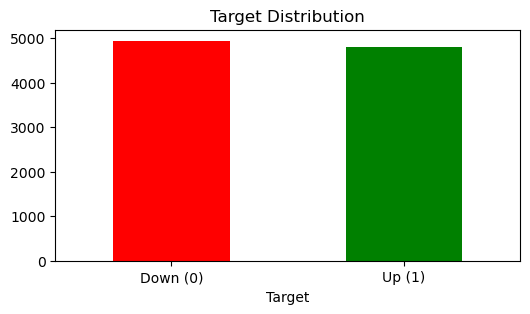

In [4]:
TARGET_SHIFT = 1

df["Target"] = (df["Close"].shift(-TARGET_SHIFT) > df["Close"]).astype(int)
df = df.iloc[:-TARGET_SHIFT]  # remove last row (no future data)

print(f"Class balance:")
print(f"  Up (1):   {df['Target'].sum()} ({df['Target'].mean():.1%})")
print(f"  Down (0): {(df['Target'] == 0).sum()} ({(df['Target'] == 0).mean():.1%})")
print(f"  Total:    {len(df)}")

plt.figure(figsize=(6, 3))
df["Target"].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Target Distribution")
plt.xticks([0, 1], ["Down (0)", "Up (1)"], rotation=0)
plt.show()

Step 4: Feature correlation heatmap

Check which features are redundant (correlation > 0.7 = suspect). Helps decide if we can drop any without losing information.

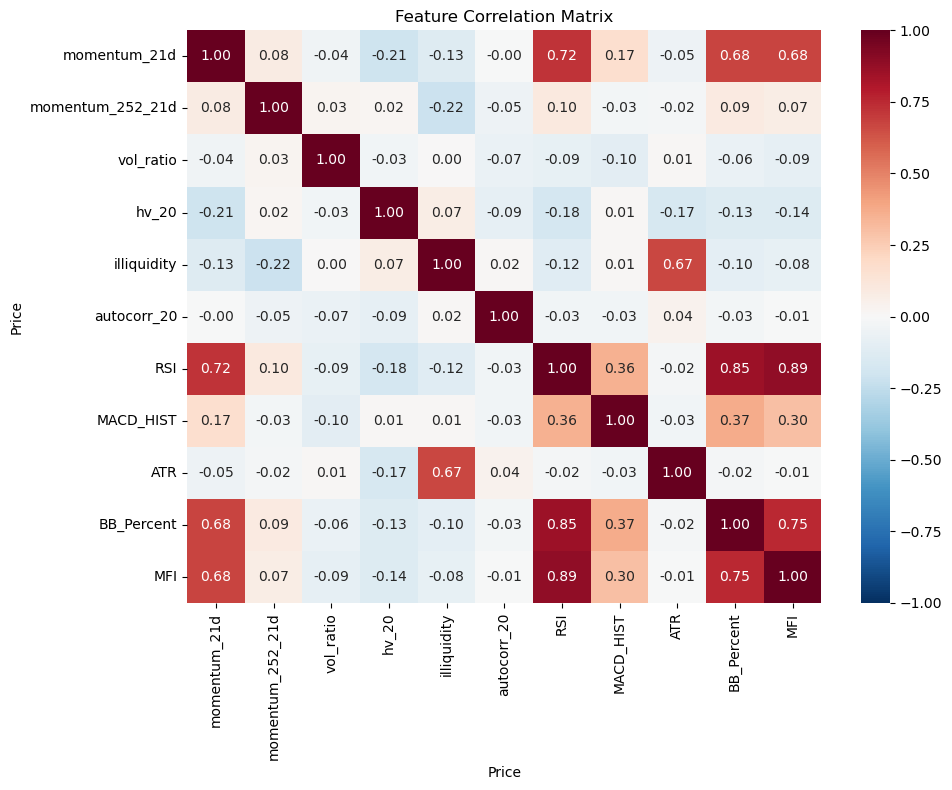

  High correlation: momentum_21d vs RSI = 0.72
  High correlation: RSI vs BB_Percent = 0.85
  High correlation: RSI vs MFI = 0.89
  High correlation: BB_Percent vs MFI = 0.75


In [5]:
plt.figure(figsize=(10, 8))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        c = abs(corr.iloc[i, j])
        if c > 0.7:
            print(f"  High correlation: {FEATURES[i]} vs {FEATURES[j]} = {c:.2f}")

Step 5: Temporal train/test split + StandardScaler

- Temporal split (80/20): train on the past, test on the future. Never shuffle time series.
- Boundary gap = TARGET_SHIFT: prevents the last training labels from leaking into the test period.
- StandardScaler: z = (x - mean) / std. Fit on train only, then transform test with the same mean/std. This prevents data leakage.

In [6]:
from sklearn.preprocessing import StandardScaler

TRAIN_RATIO = 0.8

# Temporal split with boundary gap
split_idx = int(len(df) * TRAIN_RATIO)
gap = TARGET_SHIFT
train = df.iloc[:split_idx - gap]
test = df.iloc[split_idx:]

X_train = train[FEATURES]
y_train = train["Target"]
X_test = test[FEATURES]
y_test = test["Target"]

print(f"Train: {len(X_train)} rows ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test:  {len(X_test)} rows ({test.index[0].date()} to {test.index[-1].date()})")
print(f"Gap:   {gap} rows (boundary gap to prevent label leakage)")

# StandardScaler: fit on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling
print(f"\nX_train mean (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"X_train std  (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

print(f"\nX_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Train: 7796 rows (1987-08-07 to 2018-07-12)
Test:  1950 rows (2018-07-16 to 2026-04-17)
Gap:   1 rows (boundary gap to prevent label leakage)

X_train mean (should be ~0): [ 0.  0.  0.  0. -0. -0.  0. -0.  0. -0. -0.]
X_train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

X_train shape: (7796, 11)
X_test shape:  (1950, 11)
y_train shape: (7796,)
y_test shape:  (1950,)


Summary

- X_train_scaled, X_test_scaled: scaled feature matrices ready for ML models
- y_train, y_test: binary target (1 = up, 0 = down)
- FEATURES: list of 11 feature names
- scaler: fitted StandardScaler (needed if you want to scale new data later)

These variables are ready to be used by LogReg, Random Forest, and unsupervised models (HMM, K-Means).